## **Configure Kaggle & Download Dataset**

In [ ]:
import os
import zipfile

# Move kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Install Kaggle CLI
!pip install -q kaggle

# Download and unzip UNSW-NB15 dataset
!kaggle datasets download -d dhoogla/unswnb15
with zipfile.ZipFile("unswnb15.zip", 'r') as zip_ref:
    zip_ref.extractall("unsw_nb15")


Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
  0% 0.00/11.7M [00:00<?, ?B/s]
100% 11.7M/11.7M [00:00<00:00, 954MB/s]


# **Read & Concatenate Train/Test Data**

In [ ]:
import pandas as pd

train_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_testing-set.parquet")
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                257673 non-null  float32 
 1   proto              257673 non-null  object  
 2   service            257673 non-null  category
 3   state              257673 non-null  object  
 4   spkts              257673 non-null  int16   
 5   dpkts              257673 non-null  int16   
 6   sbytes             257673 non-null  int32   
 7   dbytes             257673 non-null  int32   
 8   rate               257673 non-null  float32 
 9   sload              257673 non-null  float32 
 10  dload              257673 non-null  float32 
 11  sloss              257673 non-null  int16   
 12  dloss              257673 non-null  int16   
 13  sinpkt             257673 non-null  float32 
 14  dinpkt             257673 non-null  float32 
 15  sjit               257673 non-null

 # **Preprocess the Dataset**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy
df_clean = df.copy()



# Encode object and categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']


# **Exploratry data Analysis**

## **Visualize Label Distribution**

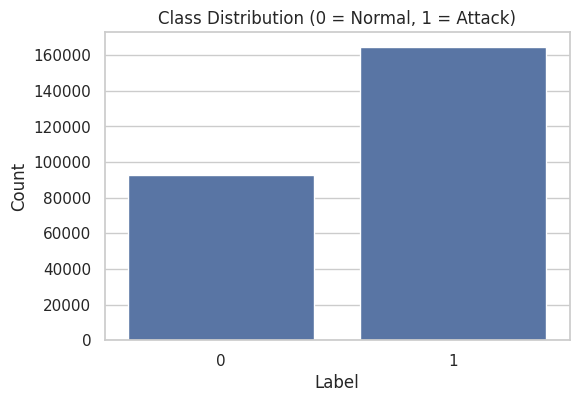

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# **Count plot to show protocol by attack Category**

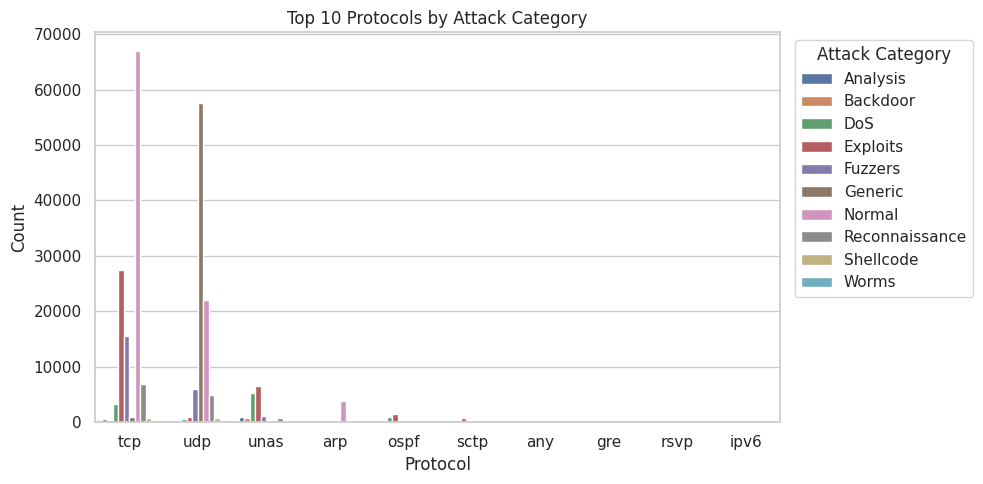

In [ ]:

# Identify top 10 most common protocols
top_protos = df['proto'].value_counts().nlargest(10).index

# Filter dataset to top protocols only
filtered_df = df[df['proto'].isin(top_protos)]

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='proto', hue='attack_cat', order=top_protos)
plt.title("Top 10 Protocols by Attack Category")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Attack Category')
plt.tight_layout()
plt.show()

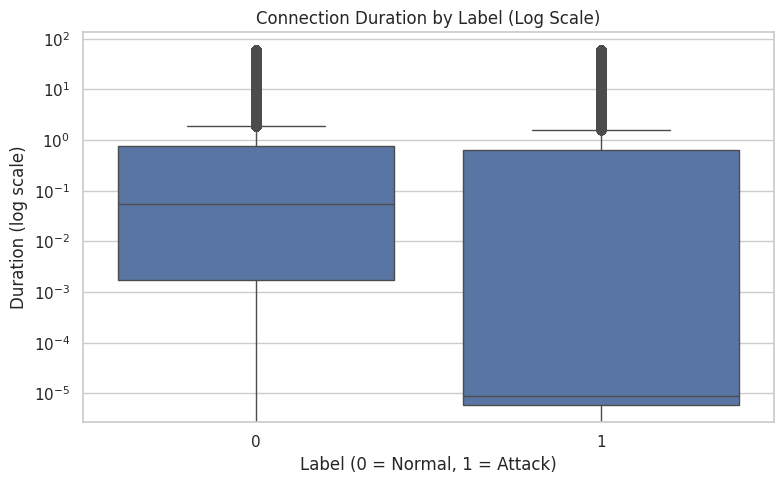

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='dur')
plt.yscale("log")
plt.title("Connection Duration by Label (Log Scale)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Duration (log scale)")
plt.tight_layout()
plt.show()

# **Split the Data Set**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)


KeyboardInterrupt: 

📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18613
           1       1.00      1.00      1.00     32922

    accuracy                           1.00     51535
   macro avg       1.00      1.00      1.00     51535
weighted avg       1.00      1.00      1.00     51535



<Figure size 600x400 with 0 Axes>

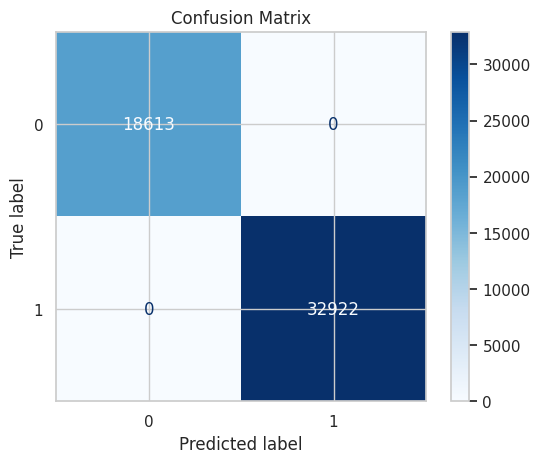

In [ ]:
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# **Model Development**

## **Machine Learning Model**


--- Training and Evaluating Logistic Regression ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 82.6983 seconds
Testing Time: 0.0179 seconds
Accuracy: 0.7989
Precision: 0.7855
Recall: 0.9426
F1-score: 0.8569

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.54      0.66     18613
           1       0.79      0.94      0.86     32922

    accuracy                           0.80     51535
   macro avg       0.81      0.74      0.76     51535
weighted avg       0.81      0.80      0.79     51535



<Figure size 600x400 with 0 Axes>

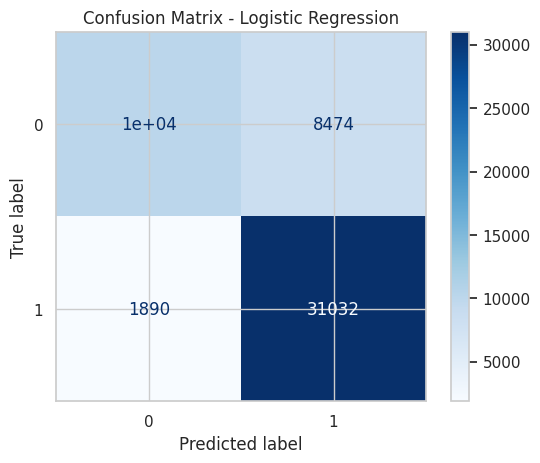

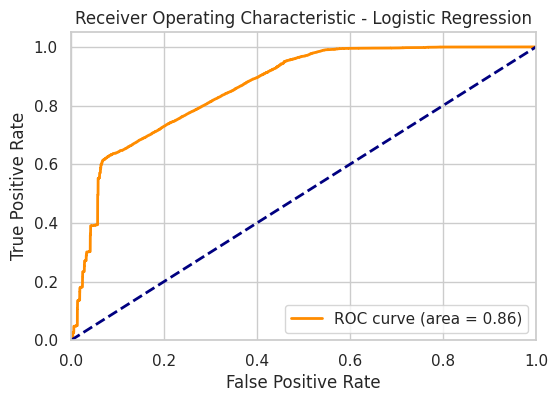


--- Training and Evaluating K-Nearest Neighbors ---
Training Time: 0.0852 seconds
Testing Time: 89.9507 seconds
Accuracy: 0.8570
Precision: 0.8720
Recall: 0.9096
F1-score: 0.8904

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.76      0.79     18613
           1       0.87      0.91      0.89     32922

    accuracy                           0.86     51535
   macro avg       0.85      0.84      0.84     51535
weighted avg       0.86      0.86      0.86     51535



<Figure size 600x400 with 0 Axes>

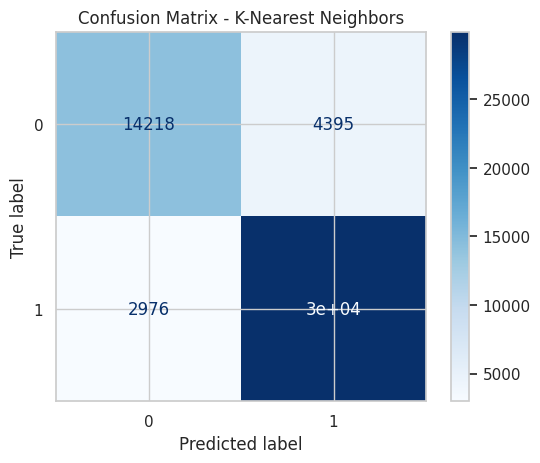

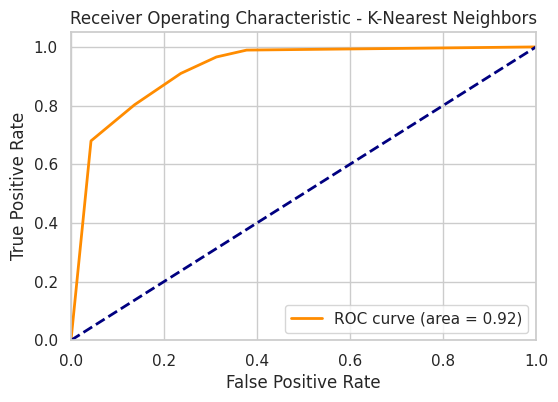


--- Training and Evaluating Gaussian Naive Bayes ---
Training Time: 0.1978 seconds
Testing Time: 0.0308 seconds
Accuracy: 0.7632
Precision: 0.7957
Recall: 0.8468
F1-score: 0.8205

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.62      0.65     18613
           1       0.80      0.85      0.82     32922

    accuracy                           0.76     51535
   macro avg       0.75      0.73      0.74     51535
weighted avg       0.76      0.76      0.76     51535



<Figure size 600x400 with 0 Axes>

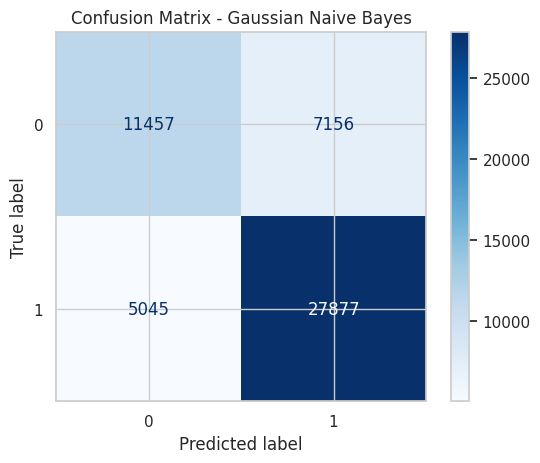

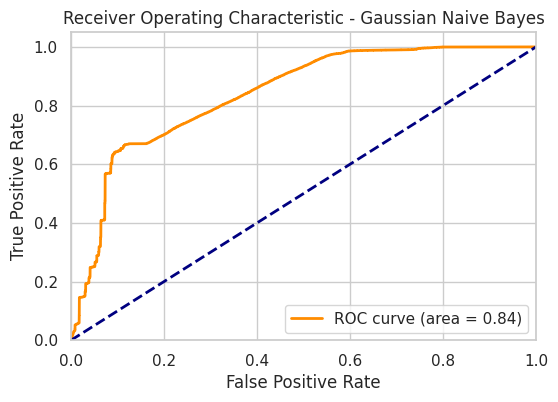


--- Training and Evaluating Neural Network ---
Training Time: 78.2580 seconds
Testing Time: 0.1182 seconds
Accuracy: 0.7772
Precision: 0.8173
Recall: 0.8389
F1-score: 0.8279

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.67      0.68     18613
           1       0.82      0.84      0.83     32922

    accuracy                           0.78     51535
   macro avg       0.76      0.75      0.76     51535
weighted avg       0.78      0.78      0.78     51535



<Figure size 600x400 with 0 Axes>

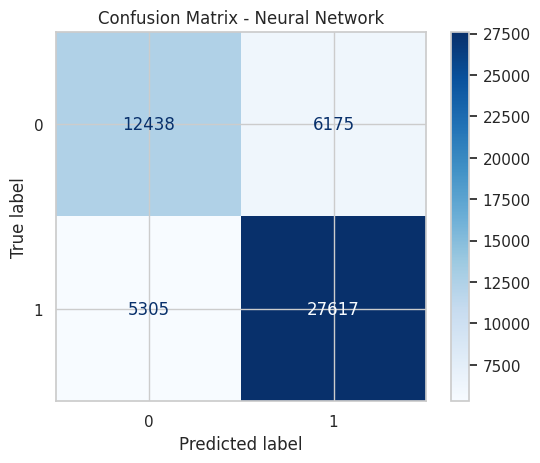

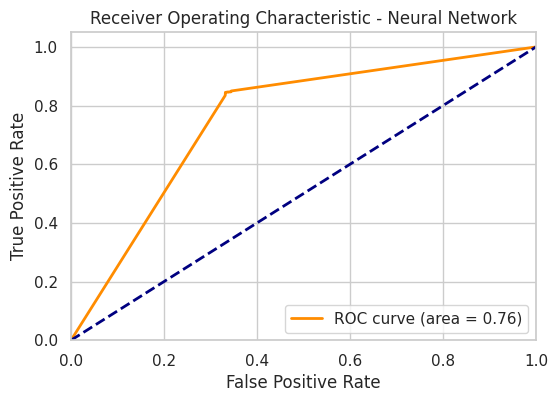


--- Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,82.698324,0.017883,0.798894,0.785501,0.942592,0.856906,0.861985
K-Nearest Neighbors,0.085220,89.950686,0.856971,0.872019,0.909605,0.890415,0.923445
Gaussian Naive Bayes,0.197771,0.030801,0.763248,0.795735,0.846759,0.820455,0.839086
Neural Network,78.257978,0.118231,0.777239,0.817264,0.838862,0.827922,0.755422


In [ ]:

import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dictionary to store models and their names
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Training time
    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Testing time and prediction
    start_test_time = time.time()
    y_pred = model.predict(X_test)
    end_test_time = time.time()
    test_time = end_test_time - start_test_time

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Classification Report
    print("\n📊 Classification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve and AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc="lower right")
        plt.show()
        results[name]["ROC AUC"] = roc_auc
    else:
        print("ROC curve not available for this model.")

# Display a summary of results
print("\n--- Model Performance Summary ---")
results_df = pd.DataFrame(results).T
results_df